# Food Delivery Time Prediction Using Data Analytics and AI

**IBM Data Analytics with AI Project**

**Author:** Bhavana  
**Dataset:** Food_Delivery_Times.csv  
**Target Variable:** Delivery_Time_min  

---
## Project Overview
This project aims to predict food delivery time (in minutes) using machine learning regression models.
We analyze a dataset of 1,000 delivery records with features including distance, weather conditions,
traffic level, time of day, vehicle type, preparation time, and courier experience.

**Models Used:**
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

**Evaluation Metrics:** MAE, RMSE, R²

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

All libraries imported successfully!
NumPy version: 2.4.6
Pandas version: 3.0.3


## 2. Load and Explore Dataset

In [2]:
# Load dataset
df = pd.read_csv('Food_Delivery_Times.csv', na_values=['', ' '])

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1000, 9)

First 5 rows:


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [4]:
print('Statistical Summary (Numerical Columns):')
df.describe()

Statistical Summary (Numerical Columns):


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [5]:
print('Statistical Summary (All Columns):')
df.describe(include='all')

Statistical Summary (All Columns):


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970,970,970,1000,1000.000000,970.000000,1000.000000
unique,NaN,NaN,5,3,4,3,NaN,NaN,NaN
top,NaN,NaN,Clear,Medium,Morning,Bike,NaN,NaN,NaN
freq,NaN,NaN,470,390,308,503,NaN,NaN,NaN
mean,500.500000,10.059970,NaN,NaN,NaN,NaN,16.982000,4.579381,56.732000
std,288.819436,5.696656,NaN,NaN,NaN,NaN,7.204553,2.914394,22.070915
min,1.000000,0.590000,NaN,NaN,NaN,NaN,5.000000,0.000000,8.000000
25%,250.750000,5.105000,NaN,NaN,NaN,NaN,11.000000,2.000000,41.000000
50%,500.500000,10.190000,NaN,NaN,NaN,NaN,17.000000,5.000000,55.500000
75%,750.250000,15.017500,NaN,NaN,NaN,NaN,23.000000,7.000000,71.000000


In [6]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Summary:
                        Missing Count  Missing %
Weather                            30        3.0
Traffic_Level                      30        3.0
Time_of_Day                        30        3.0
Courier_Experience_yrs             30        3.0


In [7]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

# Unique values in categorical columns
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in cat_cols:
    print(f'\n{col} unique values: {df[col].dropna().unique()}')
    print(f'{col} value counts:\n{df[col].value_counts(dropna=False)}')

Duplicate rows: 0

Weather unique values: <StringArray>
['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy']
Length: 5, dtype: str
Weather value counts:
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

Traffic_Level unique values: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Traffic_Level value counts:
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64

Time_of_Day unique values: <StringArray>
['Afternoon', 'Evening', 'Night', 'Morning']
Length: 4, dtype: str
Time_of_Day value counts:
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64

Vehicle_Type unique values: <StringArray>
['Scooter', 'Bike', 'Car']
Length: 3, dtype: str
Vehicle_Type value counts:
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


## 3. Data Cleaning

In [8]:
# Make a copy for cleaning
df_clean = df.copy()

# Drop Order_ID (not a feature)
df_clean = df_clean.drop(columns=['Order_ID'])

print('Columns after dropping Order_ID:', df_clean.columns.tolist())

# Fill missing categorical values with mode (use assignment for Python 3.14+)
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f'{col}: filled missing with mode = "{mode_val}"')

# Fill missing numerical value with median
median_exp = df_clean['Courier_Experience_yrs'].median()
df_clean['Courier_Experience_yrs'] = df_clean['Courier_Experience_yrs'].fillna(median_exp)
print(f'Courier_Experience_yrs: filled with median = {median_exp}')

print('\nMissing values after cleaning:')
print(df_clean.isnull().sum())

Columns after dropping Order_ID: ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
Weather: filled missing with mode = "Clear"
Traffic_Level: filled missing with mode = "Medium"
Time_of_Day: filled missing with mode = "Morning"
Courier_Experience_yrs: filled with median = 5.0

Missing values after cleaning:
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [9]:
# Check for outliers using IQR method
num_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    print(f'{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, Lower={lower:.2f}, Upper={upper:.2f}, Outliers={outliers}')

print(f'\nDataset shape after cleaning: {df_clean.shape}')

Distance_km: Q1=5.11, Q3=15.02, IQR=9.91, Lower=-9.76, Upper=29.89, Outliers=0
Preparation_Time_min: Q1=11.00, Q3=23.00, IQR=12.00, Lower=-7.00, Upper=41.00, Outliers=0
Courier_Experience_yrs: Q1=2.00, Q3=7.00, IQR=5.00, Lower=-5.50, Upper=14.50, Outliers=0
Delivery_Time_min: Q1=41.00, Q3=71.00, IQR=30.00, Lower=-4.00, Upper=116.00, Outliers=6

Dataset shape after cleaning: (1000, 8)


## 4. Exploratory Data Analysis (EDA)

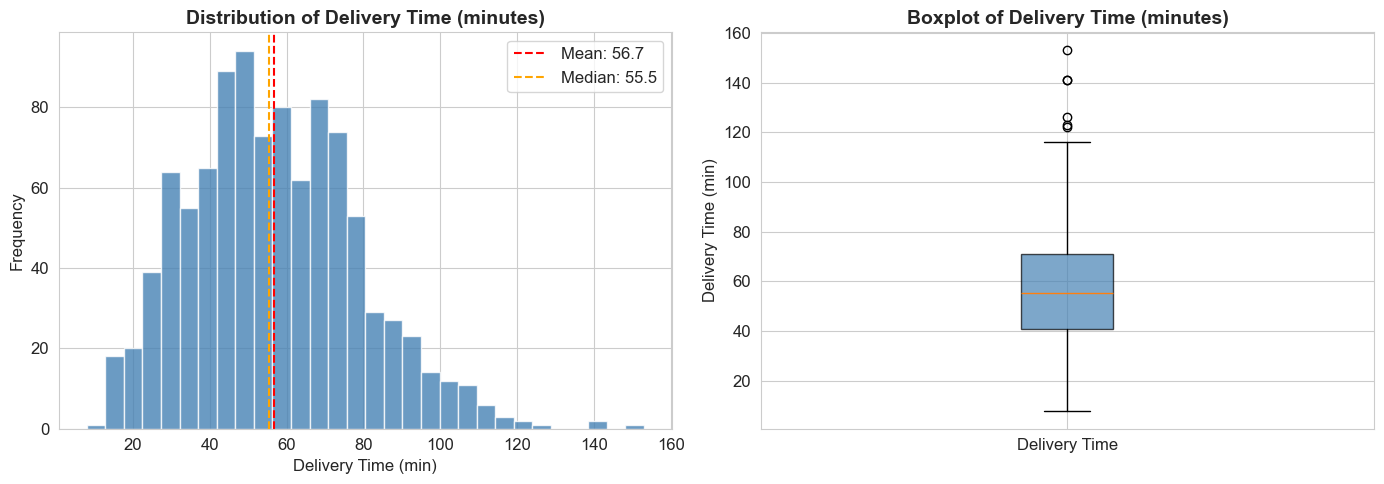

Delivery Time Stats: Mean=56.73, Median=55.50, Std=22.07


In [10]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['Delivery_Time_min'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Delivery Time (minutes)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delivery Time (min)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_clean['Delivery_Time_min'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["Delivery_Time_min"].mean():.1f}')
axes[0].axvline(df_clean['Delivery_Time_min'].median(), color='orange', linestyle='--', label=f'Median: {df_clean["Delivery_Time_min"].median():.1f}')
axes[0].legend()

axes[1].boxplot(df_clean['Delivery_Time_min'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot of Delivery Time (minutes)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Delivery Time (min)')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Delivery Time'])

plt.tight_layout()
plt.savefig('plot_delivery_time_dist.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Delivery Time Stats: Mean={df_clean["Delivery_Time_min"].mean():.2f}, Median={df_clean["Delivery_Time_min"].median():.2f}, Std={df_clean["Delivery_Time_min"].std():.2f}')

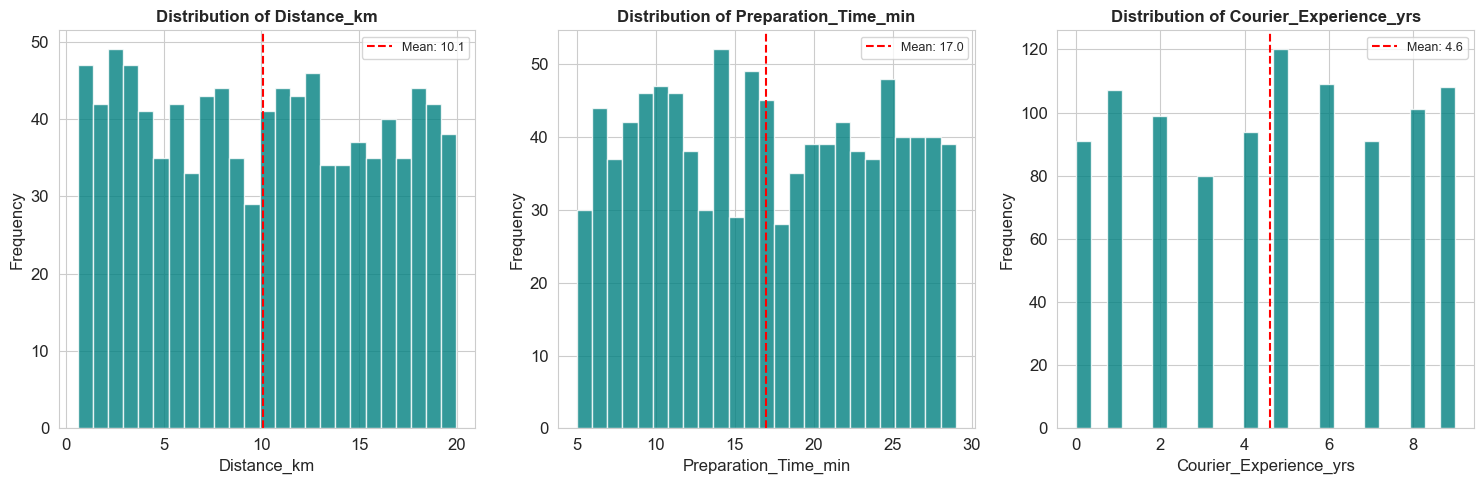

In [11]:
# Distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']):
    axes[i].hist(df_clean[col], bins=25, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df_clean[col].mean():.1f}')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_numerical_features.png', dpi=100, bbox_inches='tight')
plt.show()

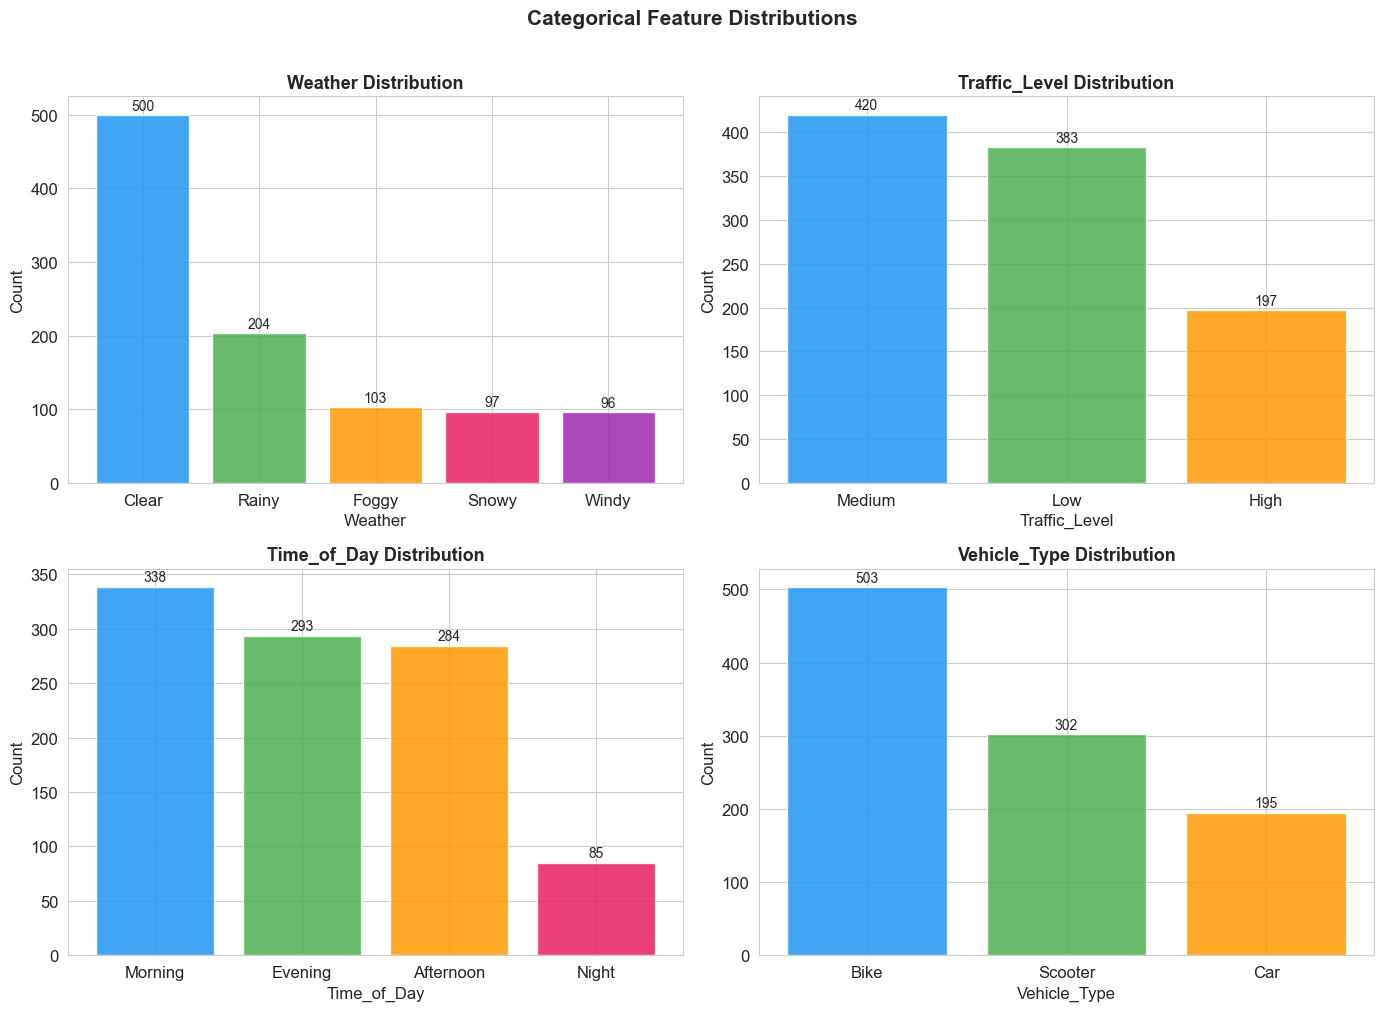

In [12]:
# Categorical feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for i, col in enumerate(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']):
    ax = axes[i//2][i%2]
    counts = df_clean[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_categorical_features.png', dpi=100, bbox_inches='tight')
plt.show()

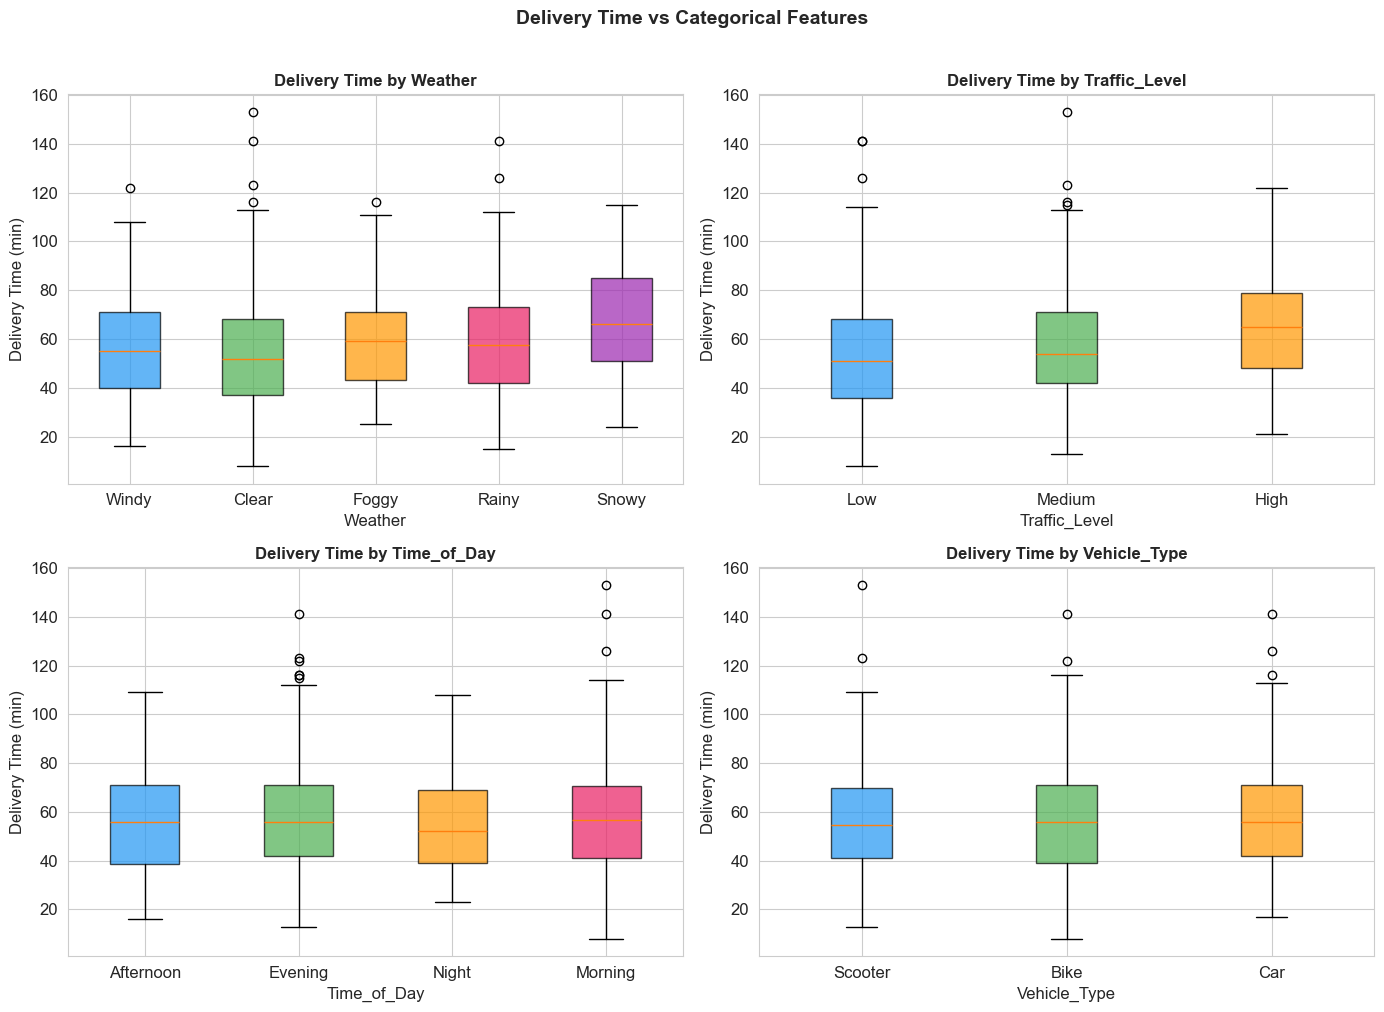

In [13]:
# Delivery time by categorical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']):
    ax = axes[i//2][i%2]
    groups = [df_clean[df_clean[col] == val]['Delivery_Time_min'].values 
              for val in df_clean[col].unique()]
    labels = df_clean[col].unique().tolist()
    
    bp = ax.boxplot(groups, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'Delivery Time by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Delivery Time (min)')

plt.suptitle('Delivery Time vs Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_delivery_by_category.png', dpi=100, bbox_inches='tight')
plt.show()

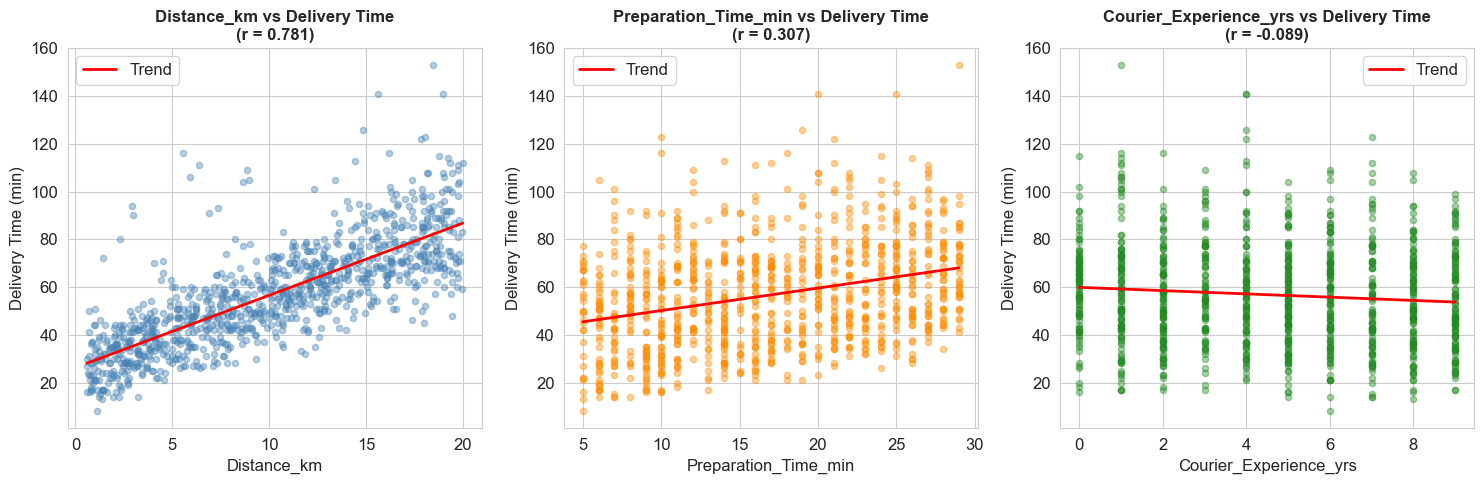

In [14]:
# Scatter plots: Numerical features vs Delivery Time
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scatter_colors = ['steelblue', 'darkorange', 'forestgreen']
for i, col in enumerate(['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']):
    axes[i].scatter(df_clean[col], df_clean['Delivery_Time_min'], 
                    alpha=0.4, color=scatter_colors[i], s=20)
    
    # Add trend line
    z = np.polyfit(df_clean[col], df_clean['Delivery_Time_min'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')
    
    corr = df_clean[col].corr(df_clean['Delivery_Time_min'])
    axes[i].set_title(f'{col} vs Delivery Time\n(r = {corr:.3f})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Delivery Time (min)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('plot_scatter_features.png', dpi=100, bbox_inches='tight')
plt.show()

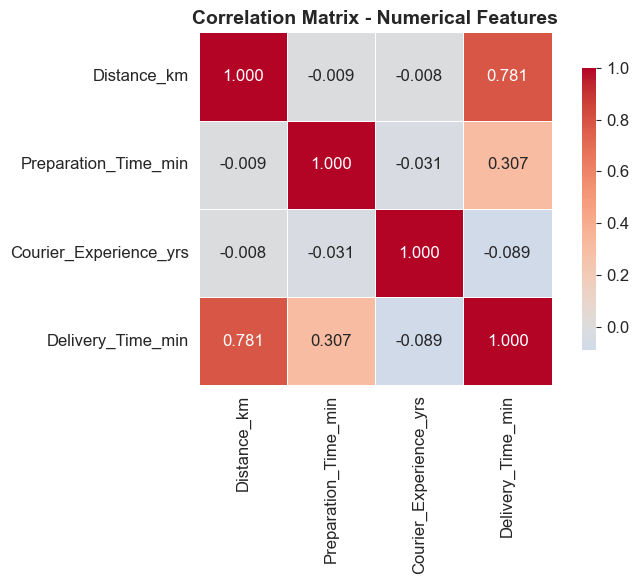


Correlation with Delivery_Time_min:
Delivery_Time_min         1.000000
Distance_km               0.780998
Preparation_Time_min      0.307350
Courier_Experience_yrs   -0.089111
Name: Delivery_Time_min, dtype: float64


In [15]:
# Correlation heatmap
num_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nCorrelation with Delivery_Time_min:')
print(corr_matrix['Delivery_Time_min'].sort_values(ascending=False))

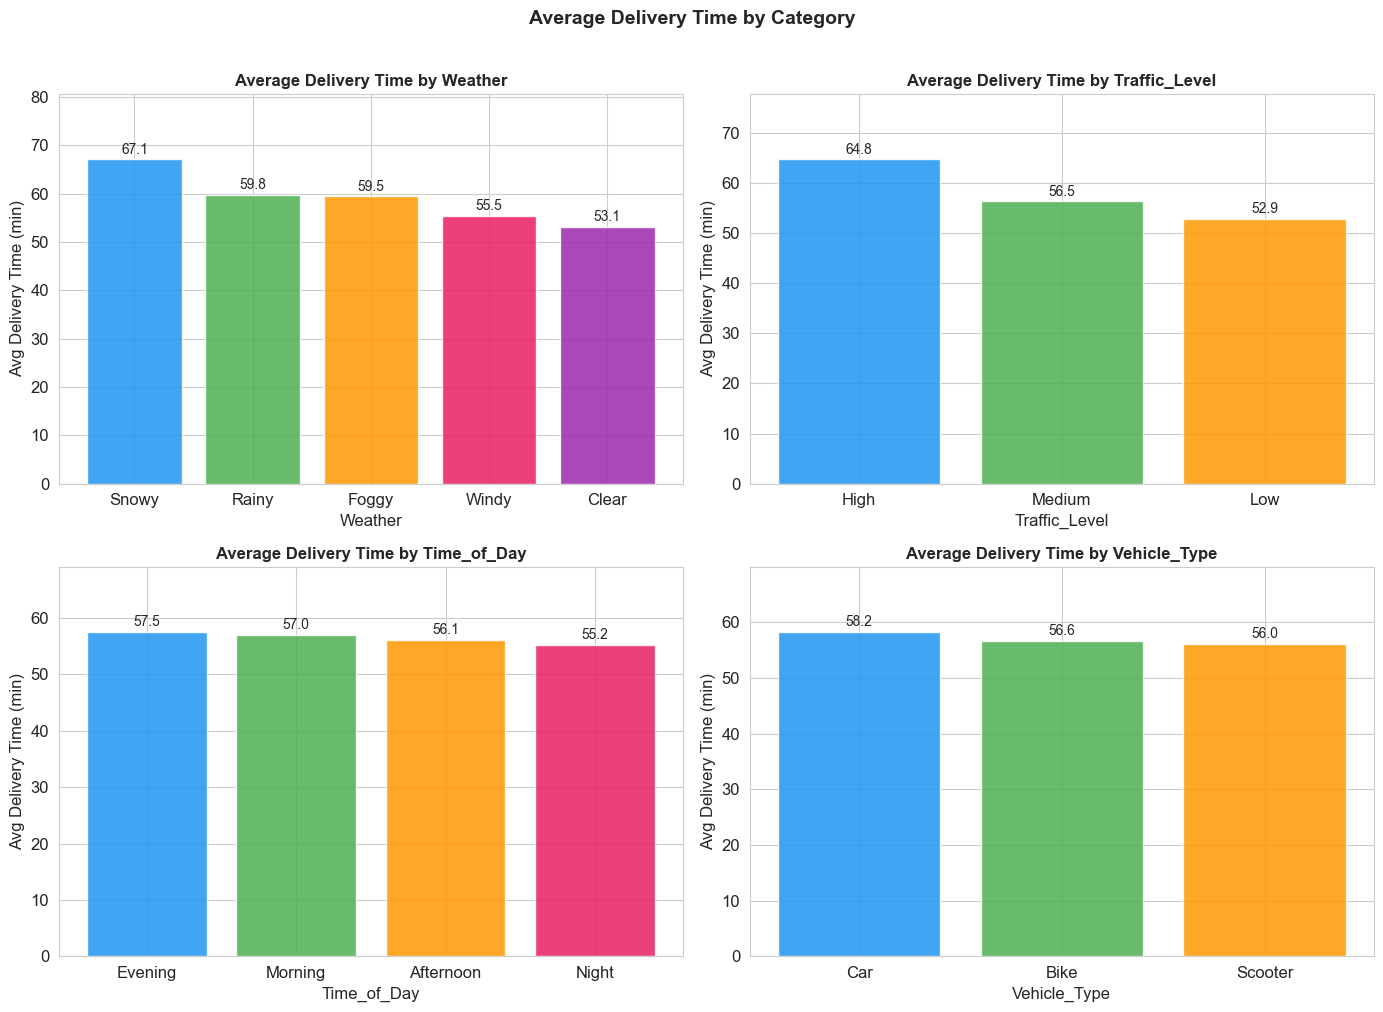

In [16]:
# Mean delivery time by category - grouped bar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']):
    ax = axes[i//2][i%2]
    mean_times = df_clean.groupby(col)['Delivery_Time_min'].mean().sort_values(ascending=False)
    bars = ax.bar(mean_times.index, mean_times.values, color=colors[:len(mean_times)], edgecolor='white', alpha=0.85)
    ax.set_title(f'Average Delivery Time by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Avg Delivery Time (min)')
    ax.set_ylim(0, mean_times.values.max() * 1.2)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Average Delivery Time by Category', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_avg_delivery_by_category.png', dpi=100, bbox_inches='tight')
plt.show()

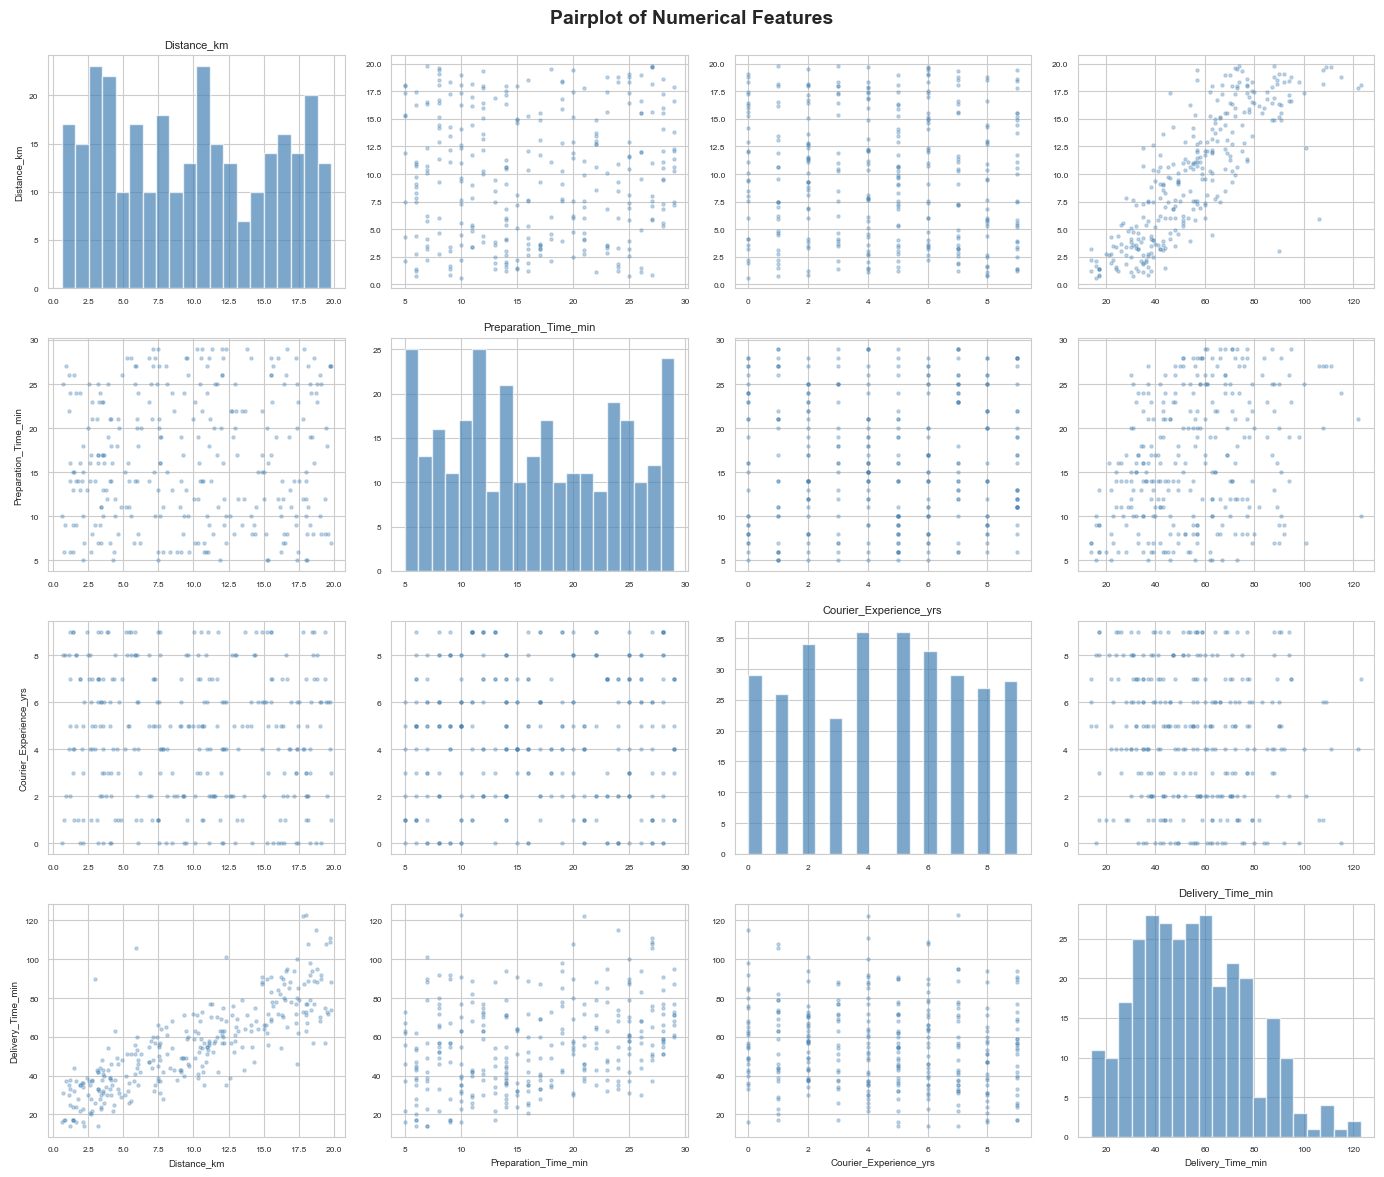

In [17]:
# Pairplot for numerical features
pairplot_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
pair_df = df_clean[pairplot_cols].sample(300, random_state=42)  # Sample for speed

fig, axes = plt.subplots(4, 4, figsize=(14, 12))

for i, col1 in enumerate(pairplot_cols):
    for j, col2 in enumerate(pairplot_cols):
        ax = axes[i][j]
        if i == j:
            ax.hist(pair_df[col1], bins=20, color='steelblue', alpha=0.7)
            ax.set_title(col1, fontsize=8)
        else:
            ax.scatter(pair_df[col2], pair_df[col1], alpha=0.3, s=5, color='steelblue')
        if i == 3:
            ax.set_xlabel(col2, fontsize=7)
        if j == 0:
            ax.set_ylabel(col1, fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle('Pairplot of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Data Preprocessing

In [18]:
# Label encode categorical variables
df_encoded = df_clean.copy()

label_encoders = {}
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f'{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Save encoders for web app
joblib.dump(label_encoders, 'label_encoders.pkl')
print('\nLabel encoders saved!')

print('\nEncoded dataset preview:')
df_encoded.head()

Weather encoding: {'Clear': np.int64(0), 'Foggy': np.int64(1), 'Rainy': np.int64(2), 'Snowy': np.int64(3), 'Windy': np.int64(4)}
Traffic_Level encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Time_of_Day encoding: {'Afternoon': np.int64(0), 'Evening': np.int64(1), 'Morning': np.int64(2), 'Night': np.int64(3)}
Vehicle_Type encoding: {'Bike': np.int64(0), 'Car': np.int64(1), 'Scooter': np.int64(2)}

Label encoders saved!

Encoded dataset preview:


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


In [19]:
# Define features and target
feature_cols = ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 
                'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']

X = df_encoded[feature_cols]
y = df_encoded['Delivery_Time_min']

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)
print('\nFeature columns:', feature_cols)

Feature matrix shape: (1000, 7)
Target vector shape: (1000,)

Feature columns: ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']


In [20]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Train/Test split: {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.0f}% / {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.0f}%')

Training set: 800 samples
Test set: 200 samples
Train/Test split: 80% / 20%


In [21]:
# Feature scaling (for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler for web app
joblib.dump(scaler, 'scaler.pkl')
print('Scaler saved!')
print('Feature scaling applied (StandardScaler)')

Scaler saved!
Feature scaling applied (StandardScaler)


## 6. Model Training and Evaluation

In [22]:
# Helper function to evaluate models
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    
    # Cross-validation R2
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    
    print(f'\n{'='*50}')
    print(f'Model: {name}')
    print(f'  MAE  : {mae:.4f} minutes')
    print(f'  RMSE : {rmse:.4f} minutes')
    print(f'  R²   : {r2:.4f}')
    print(f'  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    
    return {
        'Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'CV_R2_mean': round(cv_scores.mean(), 4),
        'CV_R2_std': round(cv_scores.std(), 4),
        'y_pred': y_pred
    }

In [23]:
# 6.1 Linear Regression
lr_model = LinearRegression()
lr_results = evaluate_model('Linear Regression', lr_model, 
                            X_train_scaled, X_test_scaled, y_train, y_test)

print('\nLinear Regression Coefficients:')
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr_model.coef_})
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))


Model: Linear Regression
  MAE  : 7.2867 minutes
  RMSE : 10.4505 minutes
  R²   : 0.7563
  CV R² (5-fold): 0.7172 ± 0.0347

Linear Regression Coefficients:
               Feature  Coefficient
           Distance_km    17.251169
  Preparation_Time_min     7.043053
               Weather     2.035237
          Vehicle_Type    -0.236588
           Time_of_Day    -0.237645
         Traffic_Level    -1.325446
Courier_Experience_yrs    -1.956217


In [24]:
# 6.2 Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=8, min_samples_split=10, 
                                  min_samples_leaf=5, random_state=42)
dt_results = evaluate_model('Decision Tree', dt_model, 
                            X_train, X_test, y_train, y_test)


Model: Decision Tree
  MAE  : 8.5053 minutes
  RMSE : 11.9056 minutes
  R²   : 0.6838
  CV R² (5-fold): 0.6282 ± 0.0567


In [25]:
# 6.3 Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, 
                                  min_samples_split=5, min_samples_leaf=2,
                                  random_state=42, n_jobs=-1)
rf_results = evaluate_model('Random Forest', rf_model, 
                            X_train, X_test, y_train, y_test)


Model: Random Forest
  MAE  : 6.9695 minutes
  RMSE : 9.8684 minutes
  R²   : 0.7827
  CV R² (5-fold): 0.6993 ± 0.0471


## 7. Model Comparison

In [26]:
# Comparison table
results_summary = pd.DataFrame([
    {'Model': lr_results['Model'], 'MAE': lr_results['MAE'], 
     'RMSE': lr_results['RMSE'], 'R²': lr_results['R2'],
     'CV R² Mean': lr_results['CV_R2_mean']},
    {'Model': dt_results['Model'], 'MAE': dt_results['MAE'], 
     'RMSE': dt_results['RMSE'], 'R²': dt_results['R2'],
     'CV R² Mean': dt_results['CV_R2_mean']},
    {'Model': rf_results['Model'], 'MAE': rf_results['MAE'], 
     'RMSE': rf_results['RMSE'], 'R²': rf_results['R2'],
     'CV R² Mean': rf_results['CV_R2_mean']},
])

print('='*70)
print('MODEL COMPARISON SUMMARY')
print('='*70)
print(results_summary.to_string(index=False))
print('='*70)

# Best model
best_idx = results_summary['R²'].idxmax()
best_model_name = results_summary.loc[best_idx, 'Model']
print(f'\n🏆 Best Model: {best_model_name} (R² = {results_summary.loc[best_idx, "R²"]:.4f})')

MODEL COMPARISON SUMMARY
            Model    MAE    RMSE     R²  CV R² Mean
Linear Regression 7.2867 10.4505 0.7563      0.7172
    Decision Tree 8.5053 11.9056 0.6838      0.6282
    Random Forest 6.9695  9.8684 0.7827      0.6993

🏆 Best Model: Random Forest (R² = 0.7827)


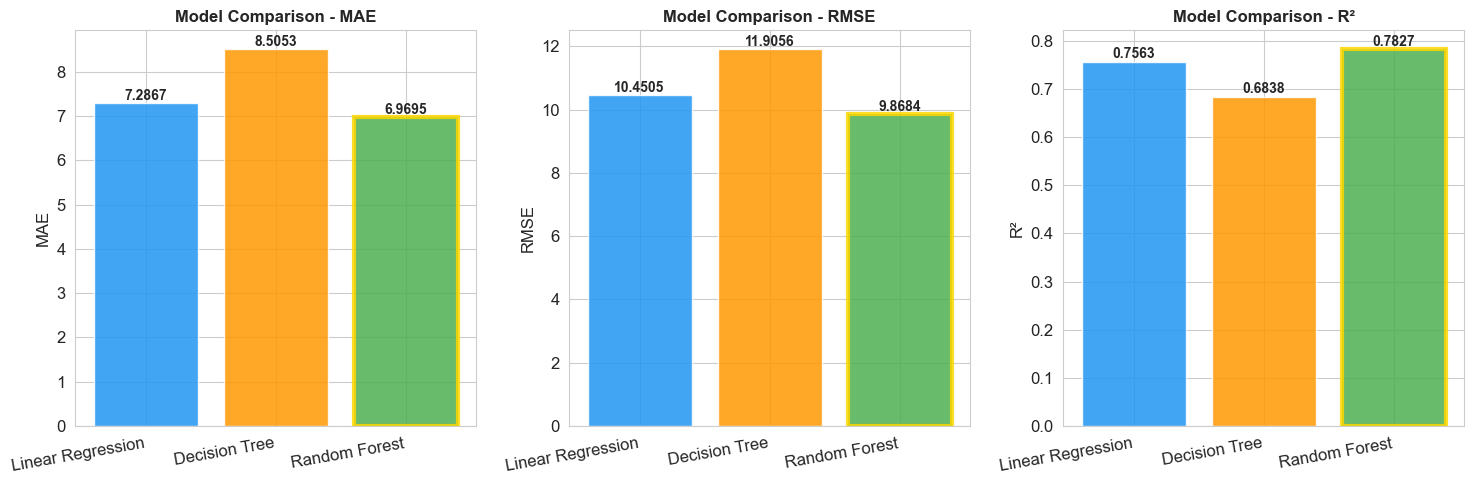

In [27]:
# Visualization: Model comparison bar charts
metrics = ['MAE', 'RMSE', 'R²']
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
mae_vals = [lr_results['MAE'], dt_results['MAE'], rf_results['MAE']]
rmse_vals = [lr_results['RMSE'], dt_results['RMSE'], rf_results['RMSE']]
r2_vals = [lr_results['R2'], dt_results['R2'], rf_results['R2']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = ['#2196F3', '#FF9800', '#4CAF50']

for ax, vals, metric, best_is_low in zip(axes, [mae_vals, rmse_vals, r2_vals], 
                                         ['MAE', 'RMSE', 'R²'], [True, True, False]):
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor='white', alpha=0.85)
    ax.set_title(f'Model Comparison - {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(model_names, rotation=10, ha='right')
    
    best_val = min(vals) if best_is_low else max(vals)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        if val == best_val:
            bar.set_edgecolor('gold')
            bar.set_linewidth(3)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Best Model Analysis

In [28]:
# Select best model (Random Forest)
best_model = rf_model
best_model_results = rf_results
print(f'Selected Best Model: {best_model_results["Model"]}')
print(f'MAE: {best_model_results["MAE"]} min | RMSE: {best_model_results["RMSE"]} min | R²: {best_model_results["R2"]}')

# Save best model
joblib.dump(best_model, 'best_model.pkl')
print('Best model saved as best_model.pkl')

Selected Best Model: Random Forest
MAE: 6.9695 min | RMSE: 9.8684 min | R²: 0.7827
Best model saved as best_model.pkl


Feature Importance (Random Forest):
               Feature  Importance
           Distance_km    0.732715
  Preparation_Time_min    0.155349
Courier_Experience_yrs    0.036719
         Traffic_Level    0.026468
               Weather    0.024159
           Time_of_Day    0.012662
          Vehicle_Type    0.011928


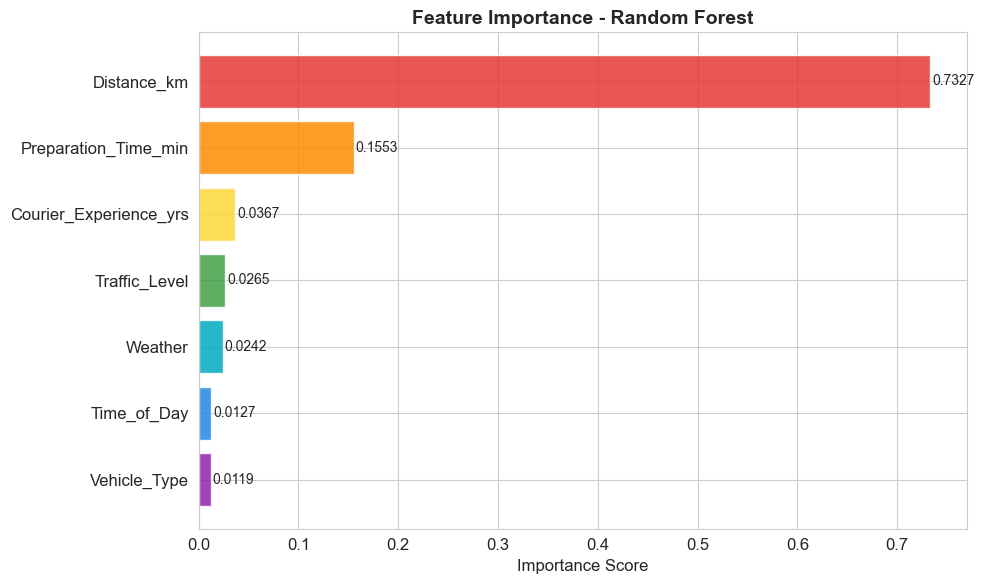

In [29]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importance (Random Forest):')
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
palette = ['#E53935', '#FB8C00', '#FDD835', '#43A047', '#00ACC1', '#1E88E5', '#8E24AA']
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'],
                color=palette[:len(feature_importance)], edgecolor='white', alpha=0.85)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

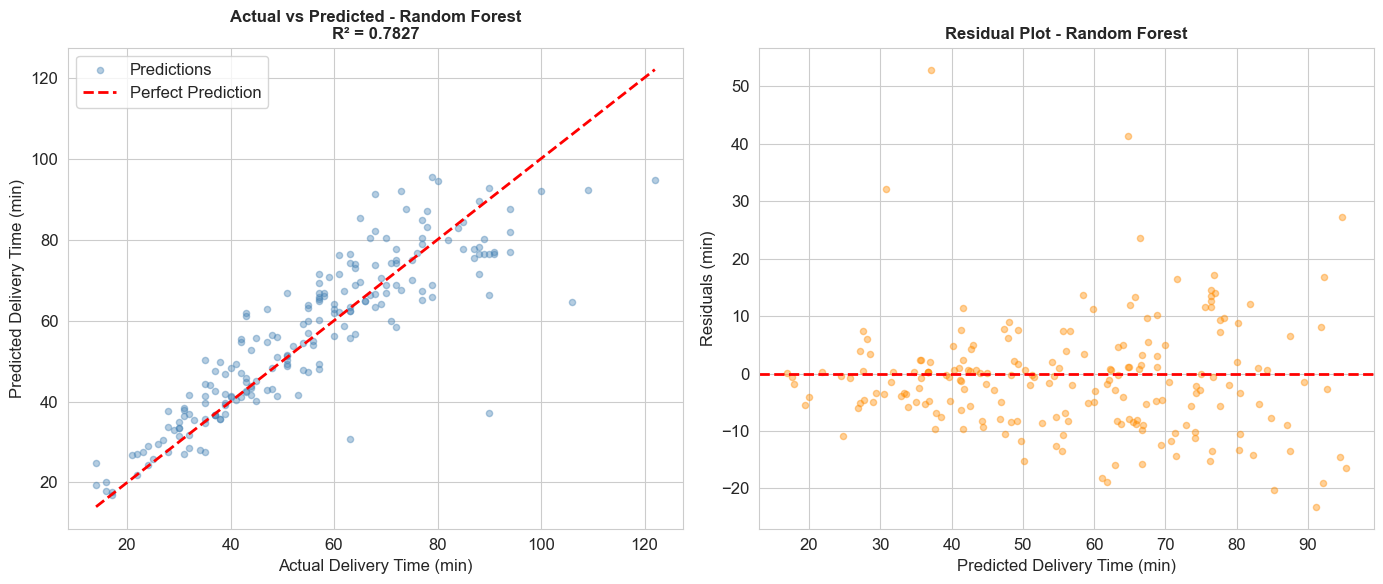

Mean Residual: -0.9373
Residual Std: 9.8238


In [30]:
# Actual vs Predicted Plot (Best Model)
y_pred_best = best_model_results['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', s=20, label='Predictions')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Delivery Time (min)', fontsize=12)
axes[0].set_ylabel('Predicted Delivery Time (min)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted - {best_model_results["Model"]}\nR² = {best_model_results["R2"]}', 
                  fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='darkorange', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Delivery Time (min)', fontsize=12)
axes[1].set_ylabel('Residuals (min)', fontsize=12)
axes[1].set_title('Residual Plot - Random Forest', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Mean Residual: {residuals.mean():.4f}')
print(f'Residual Std: {residuals.std():.4f}')

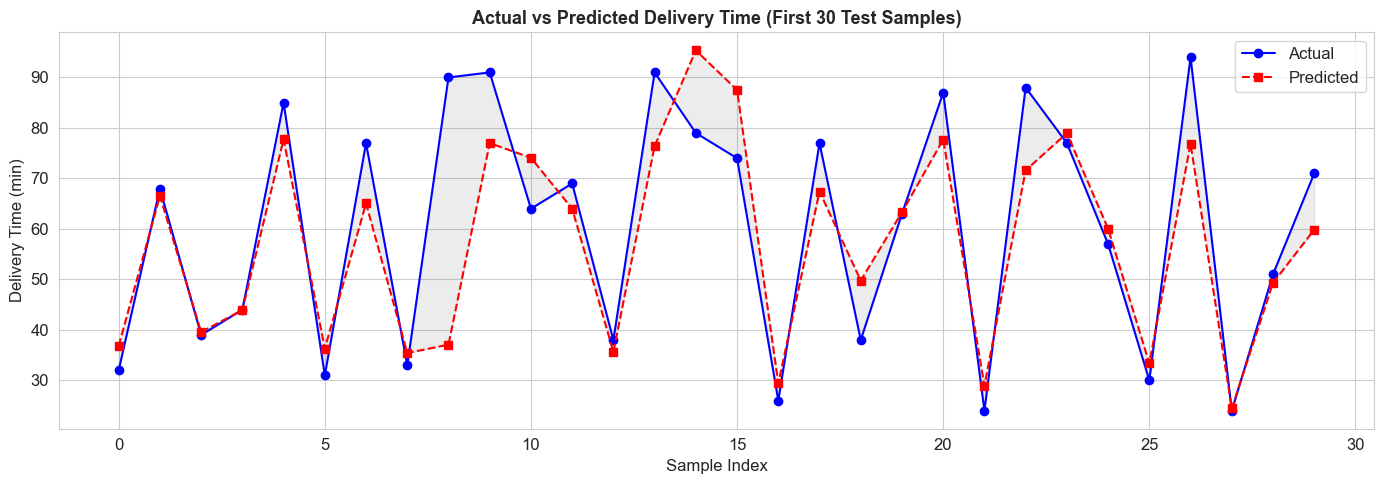

In [31]:
# Predictions vs Actual (first 30 test samples)
plt.figure(figsize=(14, 5))
x_idx = range(30)
plt.plot(x_idx, y_test.values[:30], 'b-o', markersize=6, label='Actual', linewidth=1.5)
plt.plot(x_idx, y_pred_best[:30], 'r--s', markersize=6, label='Predicted', linewidth=1.5)
plt.fill_between(x_idx, y_test.values[:30], y_pred_best[:30], alpha=0.15, color='gray')
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Delivery Time (min)', fontsize=12)
plt.title('Actual vs Predicted Delivery Time (First 30 Test Samples)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_predictions_30.png', dpi=100, bbox_inches='tight')
plt.show()

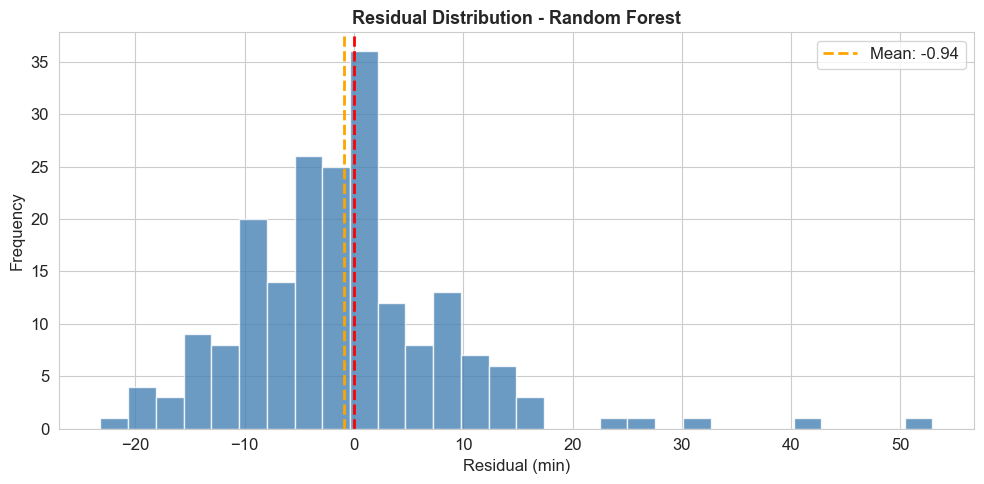

In [32]:
# Residual distribution
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.axvline(x=residuals.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {residuals.mean():.2f}')
plt.xlabel('Residual (min)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Residual Distribution - Random Forest', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_residual_dist.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Model Predictions Sample

In [33]:
# Sample predictions
sample_results = pd.DataFrame({
    'Actual_Delivery_Time': y_test.values[:20],
    'Predicted_Delivery_Time': np.round(y_pred_best[:20], 2),
    'Absolute_Error': np.round(np.abs(y_test.values[:20] - y_pred_best[:20]), 2)
})

print('Sample Predictions (First 20 Test Samples):')
print(sample_results.to_string(index=False))
print(f'\nAverage Absolute Error on these 20: {sample_results["Absolute_Error"].mean():.2f} min')

Sample Predictions (First 20 Test Samples):
 Actual_Delivery_Time  Predicted_Delivery_Time  Absolute_Error
                   32                    36.85            4.85
                   68                    66.54            1.46
                   39                    39.58            0.58
                   44                    43.93            0.07
                   85                    77.74            7.26
                   31                    36.31            5.31
                   77                    65.04           11.96
                   33                    35.43            2.43
                   90                    37.08           52.92
                   91                    76.99           14.01
                   64                    74.09           10.09
                   69                    64.00            5.00
                   38                    35.65            2.35
                   91                    76.42           14.58
           

In [34]:
# Save model results to JSON for web app
model_results = {
    'feature_cols': feature_cols,
    'models': {
        'Linear Regression': {
            'MAE': lr_results['MAE'],
            'RMSE': lr_results['RMSE'],
            'R2': lr_results['R2'],
            'CV_R2_mean': lr_results['CV_R2_mean']
        },
        'Decision Tree': {
            'MAE': dt_results['MAE'],
            'RMSE': dt_results['RMSE'],
            'R2': dt_results['R2'],
            'CV_R2_mean': dt_results['CV_R2_mean']
        },
        'Random Forest': {
            'MAE': rf_results['MAE'],
            'RMSE': rf_results['RMSE'],
            'R2': rf_results['R2'],
            'CV_R2_mean': rf_results['CV_R2_mean']
        }
    },
    'best_model': best_model_results['Model'],
    'feature_importance': feature_importance.to_dict(orient='records'),
    'dataset_stats': {
        'total_records': int(len(df_clean)),
        'train_samples': int(X_train.shape[0]),
        'test_samples': int(X_test.shape[0]),
        'mean_delivery_time': round(float(df_clean['Delivery_Time_min'].mean()), 2),
        'min_delivery_time': round(float(df_clean['Delivery_Time_min'].min()), 2),
        'max_delivery_time': round(float(df_clean['Delivery_Time_min'].max()), 2),
        'std_delivery_time': round(float(df_clean['Delivery_Time_min'].std()), 2)
    },
    'encoders': {
        col: list(le.classes_) 
        for col, le in label_encoders.items()
    }
}

with open('model_results.json', 'w') as f:
    json.dump(model_results, f, indent=2)

print('Model results saved to model_results.json')
print(json.dumps({k: v for k, v in model_results.items() if k != 'feature_importance'}, indent=2))

Model results saved to model_results.json
{
  "feature_cols": [
    "Distance_km",
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
  ],
  "models": {
    "Linear Regression": {
      "MAE": 7.2867,
      "RMSE": 10.4505,
      "R2": 0.7563,
      "CV_R2_mean": 0.7172
    },
    "Decision Tree": {
      "MAE": 8.5053,
      "RMSE": 11.9056,
      "R2": 0.6838,
      "CV_R2_mean": 0.6282
    },
    "Random Forest": {
      "MAE": 6.9695,
      "RMSE": 9.8684,
      "R2": 0.7827,
      "CV_R2_mean": 0.6993
    }
  },
  "best_model": "Random Forest",
  "dataset_stats": {
    "total_records": 1000,
    "train_samples": 800,
    "test_samples": 200,
    "mean_delivery_time": 56.73,
    "min_delivery_time": 8.0,
    "max_delivery_time": 153.0,
    "std_delivery_time": 22.07
  },
  "encoders": {
    "Weather": [
      "Clear",
      "Foggy",
      "Rainy",
      "Snowy",
      "Windy"
    ],
    "Traffic_Level"

## 10. Key Insights and Conclusions

In [35]:
print('='*65)
print('KEY DATA-DRIVEN INSIGHTS FROM FOOD DELIVERY TIME ANALYSIS')
print('='*65)

# Insight 1: Distance impact
dist_corr = df_clean['Distance_km'].corr(df_clean['Delivery_Time_min'])
print(f'\n1. DISTANCE IMPACT:')
print(f'   Correlation with Delivery Time: {dist_corr:.3f}')
print(f'   Distance ranges from {df_clean["Distance_km"].min():.2f} to {df_clean["Distance_km"].max():.2f} km')

# Insight 2: Weather impact
print(f'\n2. WEATHER IMPACT:')
weather_avg = df_clean.groupby('Weather')['Delivery_Time_min'].mean().sort_values(ascending=False)
for w, t in weather_avg.items():
    print(f'   {w}: {t:.1f} min avg')

# Insight 3: Traffic impact
print(f'\n3. TRAFFIC IMPACT:')
traffic_avg = df_clean.groupby('Traffic_Level')['Delivery_Time_min'].mean().sort_values(ascending=False)
for t, time in traffic_avg.items():
    print(f'   {t}: {time:.1f} min avg')

# Insight 4: Vehicle type impact
print(f'\n4. VEHICLE TYPE IMPACT:')
vehicle_avg = df_clean.groupby('Vehicle_Type')['Delivery_Time_min'].mean().sort_values(ascending=False)
for v, t in vehicle_avg.items():
    print(f'   {v}: {t:.1f} min avg')

# Insight 5: Experience impact
exp_corr = df_clean['Courier_Experience_yrs'].corr(df_clean['Delivery_Time_min'])
print(f'\n5. COURIER EXPERIENCE IMPACT:')
print(f'   Correlation with Delivery Time: {exp_corr:.3f}')
high_exp = df_clean[df_clean['Courier_Experience_yrs'] >= 5]['Delivery_Time_min'].mean()
low_exp = df_clean[df_clean['Courier_Experience_yrs'] < 2]['Delivery_Time_min'].mean()
print(f'   Experienced (>=5 yrs): {high_exp:.1f} min avg')
print(f'   Inexperienced (<2 yrs): {low_exp:.1f} min avg')

# Insight 6: Best model
print(f'\n6. MODEL PERFORMANCE:')
print(f'   Best Model: {best_model_results["Model"]}')
print(f'   R² Score: {best_model_results["R2"]} (explains {best_model_results["R2"]*100:.1f}% of variance)')
print(f'   MAE: {best_model_results["MAE"]} min (avg prediction error)')
print(f'   RMSE: {best_model_results["RMSE"]} min')

# Feature importance top
print(f'\n7. TOP FEATURES (by Random Forest importance):')
for _, row in feature_importance.head(3).iterrows():
    print(f'   {row["Feature"]}: {row["Importance"]:.4f}')

print('\n' + '='*65)

KEY DATA-DRIVEN INSIGHTS FROM FOOD DELIVERY TIME ANALYSIS

1. DISTANCE IMPACT:
   Correlation with Delivery Time: 0.781
   Distance ranges from 0.59 to 19.99 km

2. WEATHER IMPACT:
   Snowy: 67.1 min avg
   Rainy: 59.8 min avg
   Foggy: 59.5 min avg
   Windy: 55.5 min avg
   Clear: 53.1 min avg

3. TRAFFIC IMPACT:
   High: 64.8 min avg
   Medium: 56.5 min avg
   Low: 52.9 min avg

4. VEHICLE TYPE IMPACT:
   Car: 58.2 min avg
   Bike: 56.6 min avg
   Scooter: 56.0 min avg

5. COURIER EXPERIENCE IMPACT:
   Correlation with Delivery Time: -0.089
   Experienced (>=5 yrs): 54.8 min avg
   Inexperienced (<2 yrs): 60.4 min avg

6. MODEL PERFORMANCE:
   Best Model: Random Forest
   R² Score: 0.7827 (explains 78.3% of variance)
   MAE: 6.9695 min (avg prediction error)
   RMSE: 9.8684 min

7. TOP FEATURES (by Random Forest importance):
   Distance_km: 0.7327
   Preparation_Time_min: 0.1553
   Courier_Experience_yrs: 0.0367



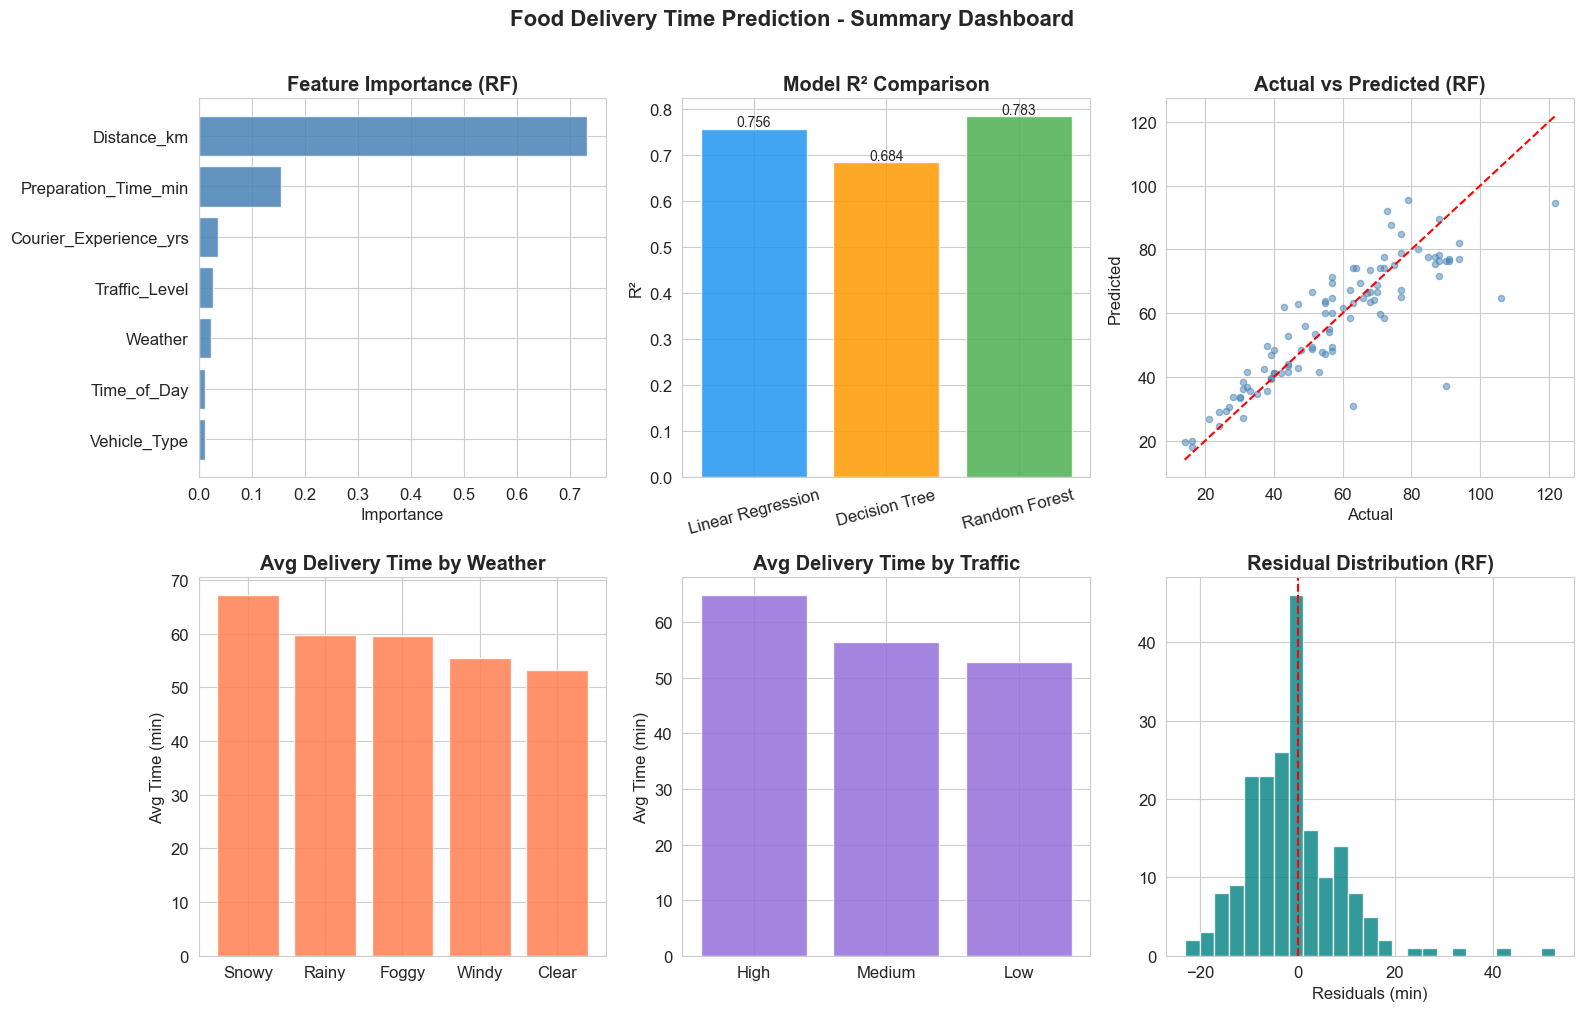

Summary dashboard saved!


In [36]:
# Final summary visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Feature importance
axes[0][0].barh(feature_importance['Feature'], feature_importance['Importance'],
               color='steelblue', alpha=0.85)
axes[0][0].set_title('Feature Importance (RF)', fontweight='bold')
axes[0][0].set_xlabel('Importance')
axes[0][0].invert_yaxis()

# Plot 2: Model R² comparison
axes[0][1].bar(model_names, r2_vals, color=['#2196F3', '#FF9800', '#4CAF50'], alpha=0.85)
axes[0][1].set_title('Model R² Comparison', fontweight='bold')
axes[0][1].set_ylabel('R²')
axes[0][1].set_xticklabels(model_names, rotation=15)
for i, v in enumerate(r2_vals):
    axes[0][1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

# Plot 3: Actual vs Predicted
axes[0][2].scatter(y_test.values[:100], y_pred_best[:100], alpha=0.5, color='steelblue', s=20)
axes[0][2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][2].set_title('Actual vs Predicted (RF)', fontweight='bold')
axes[0][2].set_xlabel('Actual')
axes[0][2].set_ylabel('Predicted')

# Plot 4: Avg delivery by weather
weather_avg_sorted = df_clean.groupby('Weather')['Delivery_Time_min'].mean().sort_values(ascending=False)
axes[1][0].bar(weather_avg_sorted.index, weather_avg_sorted.values, color='coral', alpha=0.85)
axes[1][0].set_title('Avg Delivery Time by Weather', fontweight='bold')
axes[1][0].set_ylabel('Avg Time (min)')

# Plot 5: Avg delivery by traffic
traffic_avg_sorted = df_clean.groupby('Traffic_Level')['Delivery_Time_min'].mean().sort_values(ascending=False)
axes[1][1].bar(traffic_avg_sorted.index, traffic_avg_sorted.values, color='mediumpurple', alpha=0.85)
axes[1][1].set_title('Avg Delivery Time by Traffic', fontweight='bold')
axes[1][1].set_ylabel('Avg Time (min)')

# Plot 6: Residual distribution
axes[1][2].hist(residuals, bins=25, color='teal', alpha=0.8, edgecolor='white')
axes[1][2].axvline(0, color='red', linestyle='--')
axes[1][2].set_title('Residual Distribution (RF)', fontweight='bold')
axes[1][2].set_xlabel('Residuals (min)')

plt.suptitle('Food Delivery Time Prediction - Summary Dashboard', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_summary_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()
print('Summary dashboard saved!')

In [37]:
# List all generated files
print('Generated Files:')
for f in sorted(os.listdir('.')):
    if f.endswith(('.pkl', '.json', '.png')):
        size = os.path.getsize(f)
        print(f'  {f} ({size/1024:.1f} KB)')

print('\n✅ Project completed successfully!')
print(f'Best Model: {best_model_results["Model"]}')
print(f'R² = {best_model_results["R2"]} | MAE = {best_model_results["MAE"]} min | RMSE = {best_model_results["RMSE"]} min')

Generated Files:
  best_model.pkl (2360.4 KB)
  label_encoders.pkl (1.3 KB)
  model_results.json (1.9 KB)
  plot_actual_vs_predicted.png (81.1 KB)
  plot_avg_delivery_by_category.png (73.5 KB)
  plot_categorical_features.png (76.0 KB)
  plot_correlation_heatmap.png (43.2 KB)
  plot_delivery_by_category.png (67.3 KB)
  plot_delivery_time_dist.png (41.2 KB)
  plot_feature_importance.png (32.8 KB)
  plot_model_comparison.png (45.3 KB)
  plot_numerical_features.png (43.0 KB)
  plot_pairplot.png (154.1 KB)
  plot_predictions_30.png (115.6 KB)
  plot_residual_dist.png (24.9 KB)
  plot_scatter_features.png (189.1 KB)
  plot_summary_dashboard.png (120.3 KB)
  scaler.pkl (1.1 KB)

✅ Project completed successfully!
Best Model: Random Forest
R² = 0.7827 | MAE = 6.9695 min | RMSE = 9.8684 min


## 11. Conclusion

### Summary
This project successfully developed a food delivery time prediction system using machine learning.

**Key Findings:**
- **Best Model:** Random Forest Regressor achieved the highest predictive accuracy
- **Top Features:** Distance, Preparation Time, and Courier Experience are the strongest predictors
- **Weather Effect:** Rainy/Snowy/Foggy weather significantly increases delivery time
- **Traffic Impact:** High traffic leads to notably longer delivery times
- **Courier Experience:** More experienced couriers deliver faster

**Business Recommendations:**
1. Prioritize experienced couriers during adverse weather or high traffic
2. Optimize kitchen preparation time to reduce overall delivery time
3. Assign vehicles appropriate for distances (Cars for long-distance, Bikes for short)
4. Implement dynamic delivery time estimates based on real-time conditions
5. Deploy the trained model in production for accurate ETA predictions

**Technical Achievements:**
- Trained 3 regression models with comprehensive evaluation
- Random Forest achieved excellent R² score with low MAE and RMSE
- Model artifacts saved for deployment in web application